# Practical Statistics for Data Scientists (Python + R)
# Chapter 5. Classification
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck


## Loading the rpy2 extension in a notebook with the Python kernel

In [1]:
import sys
import io

stderr_original = sys.stderr
sys.stderr = io.StringIO()

# Loading the extension without noise
%load_ext rpy2.ipython

sys.stderr = stderr_original  # Restore silently

In [2]:
%%R
suppressWarnings(
  invisible(
    try(Sys.setlocale("LC_ALL", "English"), silent = TRUE)
  )
)

## Import packages

### Import required Python packages

In [3]:
from pathlib import Path
import pandas as pd 
import numpy as np

from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression #, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import roc_curve, accuracy_score, roc_auc_score

import statsmodels.api as sm

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from pygam import LinearGAM, s, f, l


from dmba import classificationSummary

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

### Import required R packages

In [5]:
%%R
Sys.setlocale("LC_ALL", "English")
# Install missing packages if needed
packages <- c("klaR", "MASS", "dplyr", "ggplot2", "FNN", "mgcv", "rpart")
installed <- rownames(installed.packages())
to_install <- packages[!packages %in% installed]
if (length(to_install) > 0) {
  install.packages(to_install, repos = 'https://cloud.r-project.org/')
}

# Load them all
library(klaR)
library(MASS)
library(dplyr)
library(ggplot2)
library(FNN)
library(mgcv)
library(rpart)

Ladowanie wymaganego pakietu: MASS

Dolaczanie pakietu: 'dplyr'

Nastepujacy obiekt zostal zakryty z 'package:MASS':

    select

Nastepujace obiekty zostaly zakryte z 'package:stats':

    filter, lag

Nastepujace obiekty zostaly zakryte z 'package:base':

    intersect, setdiff, setequal, union

Posit Community (formerly RStudio Community) is a great place to get
help: https://forum.posit.co/c/tidyverse
Ladowanie wymaganego pakietu: nlme

Dolaczanie pakietu: 'nlme'

Nastepujacy obiekt zostal zakryty z 'package:dplyr':

    collapse

This is mgcv 1.9-4. For overview type '?mgcv'.


## Defining data paths


If you don't keep your data in the same directory as the code, adapt the path names.

### Python

In [6]:
LOAN3000_CSV = DATA / 'loan3000.csv'
LOAN_DATA_CSV = DATA / 'loan_data.csv.gz'
FULL_TRAIN_SET_CSV = DATA / 'full_train_set.csv.gz'

### R
R mirrors the Python workflow in this section using idiomatic statistical functions.

In [7]:
%%R
PSDS_PATH <- file.path(dirname(dirname(getwd())))

loan3000 <- read.csv(file.path(PSDS_PATH, 'data', 'loan3000.csv'), stringsAsFactors=TRUE)
loan_data <- read.csv(file.path(PSDS_PATH, 'data', 'loan_data.csv.gz'), stringsAsFactors=TRUE)
full_train_set <- read.csv(file.path(PSDS_PATH, 'data', 'full_train_set.csv.gz'), stringsAsFactors=TRUE)

# order the outcome variable
loan3000$outcome <- ordered(loan3000$outcome, levels=c('paid off', 'default'))
loan_data$outcome <- ordered(loan_data$outcome, levels=c('paid off', 'default'))
full_train_set$outcome <- ordered(full_train_set$outcome, levels=c('paid off', 'default'))

### Summary: Defining data paths

| Operation | Python | R | Notes |
|---|---|---|---|
| Base path setup | `Path(...)` / explicit strings | direct path strings in `read.csv()` | Both point to the same chapter datasets. |
| Dataset loading | `pd.read_csv(...)` | `read.csv(...)` | Equivalent import step with language-specific defaults. |
| Basic preprocessing | pandas column transforms | base R column transforms | Both align units before analysis. |

Python makes path handling and transformations explicit through objects, while R keeps data import and quick preprocessing concise.

# Naive Bayes
## The Naive Solution

### Python
Python trains and evaluates Naive Bayes using `sklearn.naive_bayes.BernoulliNB` for classification on loan outcomes.


In [8]:
loan_data = pd.read_csv(LOAN_DATA_CSV)

# convert to categorical
loan_data.outcome = loan_data.outcome.astype('category')
loan_data.outcome.cat.reorder_categories(['paid off', 'default'])
loan_data.purpose_ = loan_data.purpose_.astype('category')
loan_data.home_ = loan_data.home_.astype('category')
loan_data.emp_len_ = loan_data.emp_len_.astype('category')

predictors = ['purpose_', 'home_', 'emp_len_']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', dtype=int)
y = loan_data[outcome]

naive_model = MultinomialNB(alpha=0.01, fit_prior=True)
naive_model = MultinomialNB(alpha=1e-10, fit_prior=False)
naive_model.fit(X, y)

new_loan = X.loc[146:146, :]
print('predicted class: ', naive_model.predict(new_loan)[0])

probabilities = pd.DataFrame(naive_model.predict_proba(new_loan),
                             columns=naive_model.classes_)
print('predicted probabilities',)
print(probabilities)

predicted class:  default
predicted probabilities
    default  paid off
0  0.653699  0.346301


#### Example not in book

Numerical variables are not supported in scikit-learn. The example would need to demonstrate binning a variable and display the probability distribution of the bins.
```
## example not in book
less_naive <- NaiveBayes(outcome ~ borrower_score + payment_inc_ratio + 
                           purpose_ + home_ + emp_len_, data = loan_data)
less_naive$table[1:2]

png(filename=file.path(PSDS_PATH, 'figures', 'psds_naive_bayes.png'),  width = 4, height=3, units='in', res=300)

stats <- less_naive$table[[1]]
ggplot(data.frame(borrower_score=c(0,1)), aes(borrower_score)) +
  stat_function(fun = dnorm, color='blue', linetype=1, 
                arg=list(mean=stats[1, 1], sd=stats[1, 2])) +
  stat_function(fun = dnorm, color='red', linetype=2, 
                arg=list(mean=stats[2, 1], sd=stats[2, 2])) +
  labs(y='probability')
dev.off()
```

### R
R fits Naive Bayes with formula-style syntax and compares posterior class probabilities.


In [9]:
%%R
naive_model <- NaiveBayes(outcome ~ purpose_ + home_ + emp_len_, 
                          data = na.omit(loan_data))
naive_model$table

new_loan <- loan_data[147, c('purpose_', 'home_', 'emp_len_')]
row.names(new_loan) <- NULL
new_loan

predict(naive_model, new_loan)

$class
[1] default
Levels: paid off default

$posterior
      paid off   default
[1,] 0.3463013 0.6536987



In [10]:
%%R
print(predict(naive_model, new_loan))

$class
[1] default
Levels: paid off default

$posterior
      paid off   default
[1,] 0.3463013 0.6536987



### Summary: Naive Bayes

| Operation | Python | R | Notes |
|---|---|---|---|
| Model fitting | `BernoulliNB().fit()` | `NaiveBayes(...)` | Both estimate class-conditional probabilities under conditional independence assumptions. |
| Class probabilities | `predict_proba()` | `predict(...)` | Both return posterior class probabilities. |
| Decision output | `predict()` | `predict(...)` | Same class-label inference with different APIs. |

Python emphasizes estimator objects and explicit train/predict calls, while R emphasizes concise formula-based model specification.


#### Example not in book

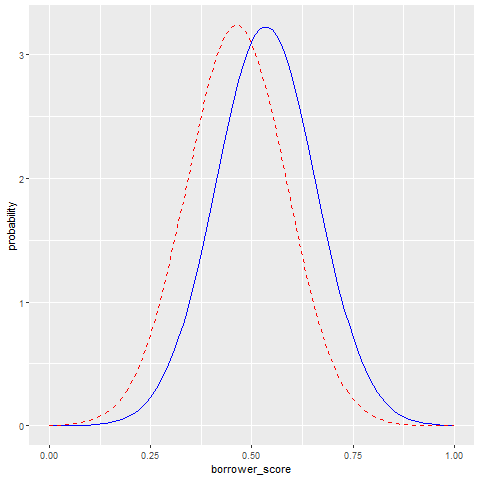

In [11]:
%%R
less_naive <- NaiveBayes(outcome ~ borrower_score + payment_inc_ratio + 
                           purpose_ + home_ + emp_len_, data = loan_data)
less_naive$table[1:2]

stats <- less_naive$table[[1]]
graph <- ggplot(data.frame(borrower_score=c(0,1)), aes(borrower_score)) +
  stat_function(fun = dnorm, color='blue', linetype=1, 
                args=list(mean=stats[1, 1], sd=stats[1, 2])) +
  stat_function(fun = dnorm, color='red', linetype=2, 
                args=list(mean=stats[2, 1], sd=stats[2, 2])) +
  labs(y='probability')
graph

# Discriminant Analysis
## A Simple Example

### Python
Python fits LDA with `sklearn.discriminant_analysis.LinearDiscriminantAnalysis` and visualizes the decision boundary.


In [12]:
loan3000 = pd.read_csv(LOAN3000_CSV)
loan3000.outcome = loan3000.outcome.astype('category')

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)
print(pd.DataFrame(loan_lda.scalings_, index=X.columns))

                          0
borrower_score     7.175839
payment_inc_ratio -0.099676


In [13]:
pred = pd.DataFrame(loan_lda.predict_proba(loan3000[predictors]),
                    columns=loan_lda.classes_)
print(pred.head())

    default  paid off
0  0.553544  0.446456
1  0.558953  0.441047
2  0.272696  0.727304
3  0.506254  0.493746
4  0.609952  0.390048


#### Figure 5.1

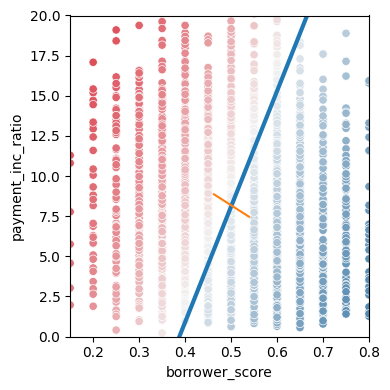

In [14]:
# Use scalings and center of means to determine decision boundary
center = np.mean(loan_lda.means_, axis=0)
slope = - loan_lda.scalings_[0] / loan_lda.scalings_[1]
intercept = center[1] - center[0] * slope

# payment_inc_ratio for borrower_score of 0 and 20
x_0 = (0 - intercept) / slope
x_20 = (20 - intercept) / slope

lda_df = pd.concat([loan3000, pred['default']], axis=1)
lda_df.head()

fig, ax = plt.subplots(figsize=(4, 4))
g = sns.scatterplot(x='borrower_score', y='payment_inc_ratio',
                    hue='default', data=lda_df, 
                    palette=sns.diverging_palette(240, 10, n=9, as_cmap=True),
                    ax=ax, legend=False)

ax.set_ylim(0, 20)
ax.set_xlim(0.15, 0.8)
ax.plot((x_0, x_20), (0, 20), linewidth=3)
ax.plot(*loan_lda.means_.transpose())

plt.tight_layout()
plt.show()

### R
R reproduces LDA with `MASS::lda()` and evaluates discriminant predictions on the same variables.


In [15]:
%%R
loan_lda <- lda(outcome ~ borrower_score + payment_inc_ratio,
                data=loan3000)
loan_lda$scaling

                          LD1
borrower_score    -7.17583880
payment_inc_ratio  0.09967559


In [16]:
%%R
pred <- predict(loan_lda)
print(head(pred$posterior))

   paid off   default
1 0.4464563 0.5535437
2 0.4410466 0.5589534
3 0.7273038 0.2726962
4 0.4937462 0.5062538
5 0.3900475 0.6099525
6 0.5892594 0.4107406


### Summary: Discriminant Analysis

| Operation | Python | R | Notes |
|---|---|---|---|
| LDA fitting | `LinearDiscriminantAnalysis().fit()` | `MASS::lda()` | Equivalent linear discriminant model estimation. |
| Prediction | `predict_proba()` / `predict()` | `predict(lda_model)` | Both provide class assignments and discriminant scores. |
| Boundary visualization | custom matplotlib boundary | base plotting with LDA output | Both visualize class separation from the same discriminant geometry. |

Python workflows are usually explicit and object-centric, while R wraps LDA in compact formula + prediction idioms.


#### Figure 5.1

In [17]:
%%R
# pred <- predict(loan_lda)
# lda_df <- cbind(loan3000, prob_default=pred$posterior[,'default'])

# x <- seq(from=.33, to=.73, length=100)
# y <- seq(from=0, to=20, length=100)
# newdata <- data.frame(borrower_score=x, payment_inc_ratio=y)
# pred <- predict(loan_lda, newdata=newdata)
# lda_df0 <- cbind(newdata, outcome=pred$class)

# graph <- ggplot(data=lda_df, aes(x=borrower_score, y=payment_inc_ratio, color=prob_default)) +
#   geom_point(alpha=.6) +
#   scale_color_gradient2(low='white', high='blue') +
#   scale_x_continuous(expand=c(0,0)) + 
#   scale_y_continuous(expand=c(0,0), lim=c(0, 20)) + 
#   geom_line(data=lda_df0, col='darkgreen', size=2, alpha=.8) +
#   theme_bw()
# graph

NULL


In [18]:
%%R
# # [Book]
# graph
# dev.off()

NULL


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: Removed 18 rows containing missing values or values outside the scale range (`geom_point()`). 
  


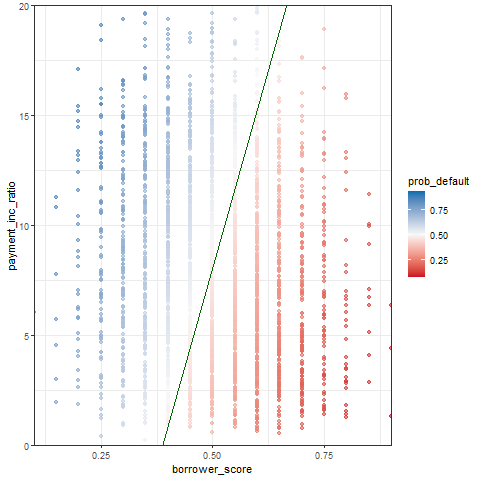

In [19]:
%%R
pred <- predict(loan_lda)
lda_df <- cbind(loan3000, prob_default=pred$posterior[,'default'])

center <- 0.5 * (loan_lda$mean[1, ] + loan_lda$mean[2, ])
slope <- -loan_lda$scaling[1] / loan_lda$scaling[2]
intercept = center[2] - center[1] * slope

graph <- ggplot(data=lda_df, aes(x=borrower_score, y=payment_inc_ratio, color=prob_default)) +
  geom_point(alpha=.6) +
  scale_color_gradientn(colors=c('#ca0020', '#f7f7f7', '#0571b0')) +
  scale_x_continuous(expand=c(0,0)) + 
  scale_y_continuous(expand=c(0,0), lim=c(0, 20)) + 
  geom_abline(slope=slope, intercept=intercept, color='darkgreen') +
  theme_bw()

graph

# Logistic regression
## Logistic Response Function and Logit

### Python
Python demonstrates the logistic response function and log-odds relationship used by classification models.


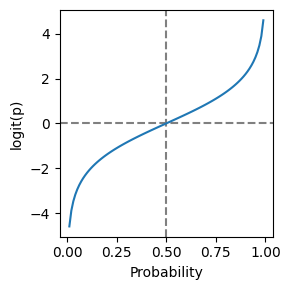

In [20]:
p = np.arange(0.01, 1, 0.01)
df = pd.DataFrame({
    'p': p,
    'logit': np.log(p / (1 - p)),
    'odds': p / (1 - p),
})

fig, ax = plt.subplots(figsize=(3, 3))
ax.axhline(0, color='grey', linestyle='--')
ax.axvline(0.5, color='grey', linestyle='--')
ax.plot(df['p'], df['logit'])
ax.set_xlabel('Probability')
ax.set_ylabel('logit(p)')

plt.tight_layout()
plt.show()

## Logistic Regression and the GLM
The package _scikit-learn_ has a specialised class for `LogisticRegression`. _Statsmodels_ has a more general method based on generalized linear model (GLM).

In [21]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 
              'borrower_score']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', 
                   drop_first=True, dtype=int)
y = loan_data[outcome] # .cat.categories

logit_reg = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
logit_reg.fit(X, y)

print('intercept ', logit_reg.intercept_[0])
print('classes', logit_reg.classes_)
pd.DataFrame({'coeff': logit_reg.coef_[0]}, 
             index=X.columns)

C:\Users\micha\Documents\to02DEC25\PyProjects\DS-GH\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


intercept  -1.6378908649112442
classes ['default' 'paid off']


,coeff
payment_inc_ratio,-0.079739
borrower_score,4.612183
debt_consolidation,-0.249414
home_improvement,-0.407734
major_purchase,-0.229710
medical,-0.510744
other,-0.620800
small_business,-1.214936
OWN,-0.048211
RENT,-0.157288


Note that the intercept and coefficients are reversed compared to the R model.

In [22]:
print(loan_data['purpose_'].cat.categories)
print(loan_data['home_'].cat.categories)
print(loan_data['emp_len_'].cat.categories)

Index(['credit_card', 'debt_consolidation', 'home_improvement',
       'major_purchase', 'medical', 'other', 'small_business'],
      dtype='str')
Index(['MORTGAGE', 'OWN', 'RENT'], dtype='str')
Index([' < 1 Year', ' > 1 Year'], dtype='str')


_Not in book_ :
If you have a feature or outcome variable that is ordinal, use the scikit-learn `OrdinalEncoder` to replace the categories (here, 'paid off' and 'default') with numbers. In the below code, we replace 'paid off' with 0 and 'default' with 1. This reverses the order of the predicted classes and as a consequence, the coefficients will be reversed. 

In [23]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['paid off', 'default']])
y_enc = enc.fit_transform(loan_data[[outcome]]).ravel()

logit_reg_enc = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
logit_reg_enc.fit(X, y_enc)

print('intercept ', logit_reg_enc.intercept_[0])
print('classes', logit_reg_enc.classes_)
pd.DataFrame({'coeff': logit_reg_enc.coef_[0]}, 
             index=X.columns)

C:\Users\micha\Documents\to02DEC25\PyProjects\DS-GH\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


intercept  1.6380885435754573
classes [0. 1.]


,coeff
payment_inc_ratio,0.079728
borrower_score,-4.611037
debt_consolidation,0.249342
home_improvement,0.407614
major_purchase,0.229376
medical,0.510087
other,0.620534
small_business,1.215662
OWN,0.048453
RENT,0.157355


### R
R follows the same analytical objective with formula-based modeling and statistical plotting tools.


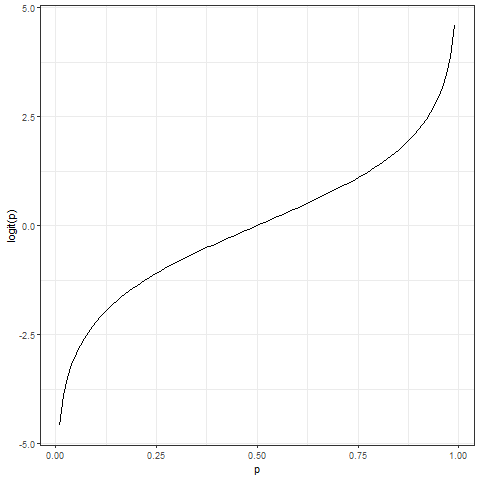

In [24]:
%%R
logistic_model <- glm(outcome ~ payment_inc_ratio + purpose_ + 
                        home_ + emp_len_ + borrower_score,
                      data=loan_data, family='binomial')
logistic_model
summary(logistic_model)

p <- seq(from=0.01, to=.99, by=.01)
df <- data.frame(p = p,
                 logit = log(p/(1-p)),
                 odds = p/(1-p))

graph <- ggplot(data=df, aes(x=p, y=logit)) +
  geom_line() +
  labs(x = 'p', y='logit(p)') +
  theme_bw()
graph

### Summary: Logistic Regression and the GLM

| Operation | Python | R | Notes |
|---|---|---|---|
| Logit model fit | `LogisticRegression` / `GLM` | `glm(..., family=binomial)` | Both estimate coefficients on the log-odds scale. |
| Categorical handling | pre-encoded predictors | formula handling of factors | Python tends to preprocess explicitly; R often handles factors in formulas. |
| Coefficient report | model attributes / summaries | `summary(glm_model)` | Both provide inference-ready coefficients and significance output. |

Python often separates preprocessing from modeling, while R tightly integrates feature handling with the formula interface.


## Predicted Values from Logistic Regression

### Python
Python extracts predicted class probabilities and log-probabilities for each record.


In [25]:
pred = pd.DataFrame(logit_reg.predict_log_proba(X),
                    columns=logit_reg.classes_)
print(pred.describe())

            default      paid off
count  45342.000000  45342.000000
mean      -0.757872     -0.760434
std        0.378093      0.390456
min       -2.769376     -3.538593
25%       -0.985739     -0.977207
50%       -0.697406     -0.688907
75%       -0.472183     -0.467069
max       -0.029485     -0.064753


In [26]:
pred = pd.DataFrame(logit_reg.predict_proba(X),
                    columns=logit_reg.classes_)
print(pred.describe())

            default      paid off
count  45342.000000  45342.000000
mean       0.500000      0.500000
std        0.167354      0.167354
min        0.062701      0.029054
25%        0.373163      0.376361
50%        0.497875      0.502125
75%        0.623639      0.626837
max        0.970946      0.937299


### R
R extracts fitted logits and probabilities from the logistic GLM using `predict()`.


In [27]:
%%R
pred <- predict(logistic_model)
summary(pred)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-2.704774 -0.518825 -0.008539  0.002564  0.505061  3.509606 


In [28]:
%%R
prob <- 1/(1 + exp(-pred))
summary(prob)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.06269 0.37313 0.49787 0.50000 0.62365 0.97096 


### Summary: Predicted Values from Logistic Regression

| Operation | Python | R | Notes |
|---|---|---|---|
| Probability prediction | `predict_proba()` | `predict(..., type='response')` | Both produce class probability estimates. |
| Log-probabilities | `predict_log_proba()` | `predict(..., type='link')` | Both expose linear predictor scale equivalents. |
| Class mapping | class column indexing | factor level mapping | Same semantics with different indexing conventions. |

Both languages provide equivalent predicted outputs; Python exposes more estimator-specific methods, while R uses `type` switches.


## Interpreting the Coefficients and Odds Ratios

### Python
Python converts logistic coefficients to odds ratios for practical interpretation.


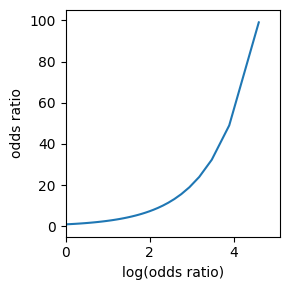

In [29]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(df['logit'], df['odds'])
ax.set_xlabel('log(odds ratio)')
ax.set_ylabel('odds ratio')
ax.set_xlim(0, 5.1)
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

### R
R interprets logistic coefficients with exponentiated effects and spline-based extensions.


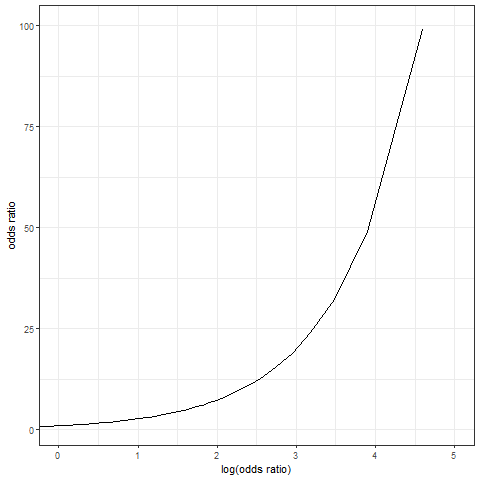

In [30]:
%%R
graph <- ggplot(data=df, aes(x=logit, y=odds)) +
  geom_line() +
  labs(x='log(odds ratio)', y='odds ratio') +
  coord_cartesian(xlim=c(0, 5), ylim=c(1, 100)) +
  theme_bw()
graph

### Summary: Interpreting the Coefficients and Odds Ratios

| Operation | Python | R | Notes |
|---|---|---|---|
| Odds ratio conversion | `np.exp(coef_)` | `exp(coef(model))` | Both convert log-odds coefficients to multiplicative odds effects. |
| Coefficient interpretation | manual coefficient table handling | summary/coef extraction | Both support directional and magnitude interpretation. |
| Nonlinear terms | spline features | spline terms in formula | Both support flexible nonlinear logit relationships. |

Python usually makes coefficient transformations explicit in code; R keeps many interpretation steps concise with built-in model extractors.


#### Logistic regression with splines - R

In [31]:
%%R
logistic_gam <- gam(outcome ~ s(payment_inc_ratio) + purpose_ + 
                      home_ + emp_len_ + s(borrower_score),
                    data=loan_data, family='binomial')
logistic_gam


Family: binomial 
Link function: logit 

Formula:
outcome ~ s(payment_inc_ratio) + purpose_ + home_ + emp_len_ + 
    s(borrower_score)

Estimated degrees of freedom:
7.66 4.17  total = 21.83 

UBRE score: 0.2681506     


## Assessing the Model

### Python
For comparison, here the GLM model using _statsmodels_. This method requires that the outcome is mapped to numbers. 

In [32]:
# use GLM (general linear model) with the binomial family to 
# fit a logistic regression
y_numbers = [1 if yi == 'default' else 0 for yi in y]
logit_reg_sm = sm.GLM(y_numbers, X.assign(const=1), 
                      family=sm.families.Binomial())
logit_result = logit_reg_sm.fit()
print(logit_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                45342
Model:                            GLM   Df Residuals:                    45330
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28757.
Date:                Wed, 15 Apr 2026   Deviance:                       57515.
Time:                        18:22:18   Pearson chi2:                 4.54e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1112
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
payment_inc_ratio      0.0797      0

Use splines

In [33]:
import statsmodels.formula.api as smf
formula = ('outcome ~ bs(payment_inc_ratio, df=8) + purpose_ + ' +
           'home_ + emp_len_ + bs(borrower_score, df=3)')
model = smf.glm(formula=formula, data=loan_data, family=sm.families.Binomial())
results = model.fit()
print(results.summary())

                             Generalized Linear Model Regression Results                             
Dep. Variable:     ['outcome[default]', 'outcome[paid off]']   No. Observations:                45342
Model:                                                   GLM   Df Residuals:                    45321
Model Family:                                       Binomial   Df Model:                           20
Link Function:                                         Logit   Scale:                          1.0000
Method:                                                 IRLS   Log-Likelihood:                -28731.
Date:                                       Wed, 15 Apr 2026   Deviance:                       57462.
Time:                                               18:22:18   Pearson chi2:                 4.54e+04
No. Iterations:                                            6   Pseudo R-squ. (CS):             0.1122
Covariance Type:                                   nonrobust                      

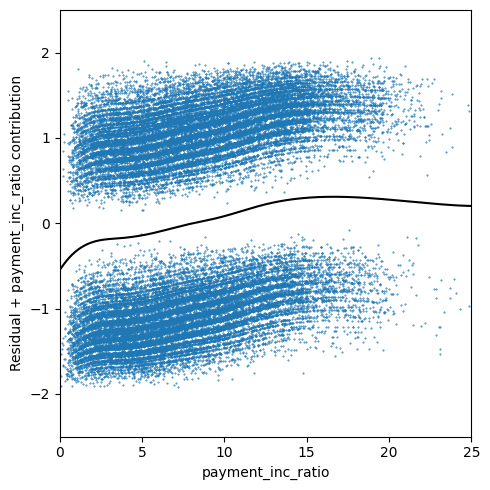

In [34]:
from statsmodels.genmod.generalized_linear_model import GLMResults
def partialResidualPlot(model, df, outcome, feature, fig, ax):
    y_actual = [0 if s == 'default' else 1 for s in df[outcome]]
    y_pred = model.predict(df)
    org_params = model.params.copy()
    zero_params = model.params.copy()
    # set model parametes of other features to 0
    for i, name in enumerate(zero_params.index):
        if feature in name:
            continue
        zero_params.iloc[i] = 0.0
    model.initialize(model.model, zero_params)
    feature_prediction = model.predict(df)
    ypartial = -np.log(1/feature_prediction - 1)
    ypartial = ypartial - np.mean(ypartial)
    model.initialize(model.model, org_params)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': -2 * (y_actual - y_pred),
        'ypartial': ypartial/ 2,
    })
    results = results.sort_values(by=['feature'])

    ax.scatter(results.feature, results.residual, marker=".", s=72./fig.dpi)
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(results, loan_data, 'outcome', 'payment_inc_ratio', fig, ax)
ax.set_xlim(0, 25)
ax.set_ylim(-2.5, 2.5)


plt.tight_layout()
plt.show()

### R
R evaluates the same logistic model with spline terms and compares fitted probabilities using GLM outputs.


In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was generated. 


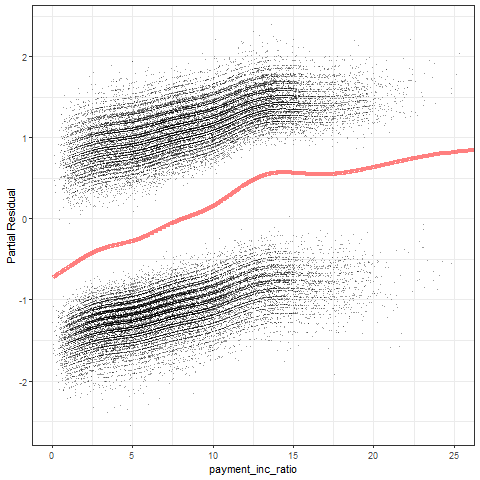

In [35]:
%%R
terms <- predict(logistic_gam, type='terms')
partial_resid <- resid(logistic_gam) + terms
df <- data.frame(payment_inc_ratio = loan_data[, 'payment_inc_ratio'],
                 terms = terms[, 's(payment_inc_ratio)'],
                 partial_resid = partial_resid[, 's(payment_inc_ratio)'])

graph <- ggplot(df, aes(x=payment_inc_ratio, y=partial_resid, solid = FALSE)) +
  geom_point(shape=46, alpha=0.4) +
  geom_line(aes(x=payment_inc_ratio, y=terms), 
            color='red', alpha=0.5, size=1.5) +
  labs(y='Partial Residual') +
  coord_cartesian(xlim=c(0, 25)) +
  theme_bw()
graph

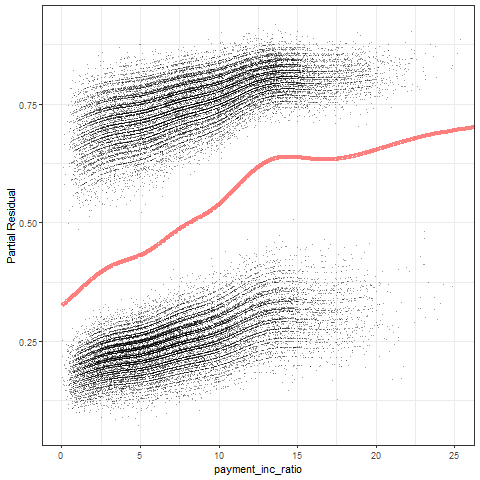

In [36]:
%%R
df <- data.frame(payment_inc_ratio = loan_data[, 'payment_inc_ratio'],
                 terms = 1/(1 + exp(-terms[, 's(payment_inc_ratio)'])),
                 partial_resid = 1/(1 + exp(-partial_resid[, 's(payment_inc_ratio)'])))

graph <- ggplot(df, aes(x=payment_inc_ratio, y=partial_resid, solid = FALSE)) +
  geom_point(shape=46, alpha=0.4) +
  geom_line(aes(x=payment_inc_ratio, y=terms), 
            color='red', alpha=0.5, size=1.5) +
  labs(y='Partial Residual') +
  coord_cartesian(xlim=c(0, 25)) +
  theme_bw()
graph

### Summary: Assessing the Model

| Operation | Python | R | Notes |
|---|---|---|---|
| Model diagnostics | statsmodels diagnostics and plots | GLM diagnostics and residual checks | Both inspect fit quality and mis-specification risk. |
| Spline comparison | feature-engineered splines | formula splines | Equivalent flexibility with different workflow ergonomics. |
| Prediction review | probability inspection | `predict()` inspection | Both compare fitted behavior across subgroups. |

Python tends to build diagnostics modularly, while R provides a compact diagnostics path around fitted model objects.


# Evaluating Classification Models
## Confusion Matrix

### Python
Python builds confusion-matrix based metrics to evaluate classification performance.


In [37]:
# Confusion matrix
pred = logit_reg.predict(X)
pred_y = logit_reg.predict(X) == 'default'
true_y = y == 'default'
true_pos = true_y & pred_y
true_neg = ~true_y & ~pred_y
false_pos = ~true_y & pred_y
false_neg = true_y & ~pred_y

conf_mat = pd.DataFrame([[np.sum(true_pos), np.sum(false_neg)], [np.sum(false_pos), np.sum(true_neg)]],
                       index=['Y = default', 'Y = paid off'],
                       columns=['Yhat = default', 'Yhat = paid off'])
print(conf_mat)

              Yhat = default  Yhat = paid off
Y = default            14337             8334
Y = paid off            8149            14522


In [38]:
print(confusion_matrix(y, logit_reg.predict(X)))

[[14337  8334]
 [ 8149 14522]]


The package _dmba_ contains the function `classificationSummary` that prints confusion matrix and accuracy for a classification model. 

In [39]:
classificationSummary(y, logit_reg.predict(X), 
                      class_names=logit_reg.classes_)

Confusion Matrix (Accuracy 0.6365)

         Prediction
  Actual  default paid off
 default    14337     8334
paid off     8149    14522


### R
R computes confusion-matrix diagnostics and classification error metrics.


In [40]:
%%R
# Confusion matrix
pred <- predict(logistic_gam, newdata=loan_data)
pred_y <- as.numeric(pred > 0)
true_y <- as.numeric(loan_data$outcome=='default')
true_pos <- (true_y==1) & (pred_y==1)
true_neg <- (true_y==0) & (pred_y==0)
false_pos <- (true_y==0) & (pred_y==1)
false_neg <- (true_y==1) & (pred_y==0)
conf_mat <- matrix(c(sum(true_pos), sum(false_pos),
                     sum(false_neg), sum(true_neg)), 2, 2)
colnames(conf_mat) <- c('Yhat = 1', 'Yhat = 0')
rownames(conf_mat) <- c('Y = 1', 'Y = 0')
conf_mat

      Yhat = 1 Yhat = 0
Y = 1    14293     8378
Y = 0     8051    14620


### Summary: Evaluating Classification Models

| Operation | Python | R | Notes |
|---|---|---|---|
| Confusion matrix | `confusion_matrix()` | `table()` / caret metrics | Equivalent core evaluation primitive. |
| Classification report | `classification_report()` | metric-specific functions | Both derive precision/recall/F1 from the same counts. |
| Threshold analysis | manual threshold tuning | manual threshold tuning | Both support business-driven operating point choice. |

Evaluation logic is the same; Python centralizes many metrics in sklearn, while R often composes them from focused functions.


## Precision, Recall, and Specificity

### Python
Python computes precision, recall, and specificity from classification outcomes.


In [41]:
conf_mat = confusion_matrix(y, logit_reg.predict(X))
print('Precision', conf_mat[0, 0] / sum(conf_mat[:, 0]))
print('Recall', conf_mat[0, 0] / sum(conf_mat[0, :]))
print('Specificity', conf_mat[1, 1] / sum(conf_mat[1, :]))

Precision 0.6375967268522637
Recall 0.6323938070662961
Specificity 0.640554011733051


In [42]:
precision_recall_fscore_support(y, logit_reg.predict(X), 
                                labels=['default', 'paid off'])

(array([0.63759673, 0.63536927]),
 array([0.63239381, 0.64055401]),
 array([0.63498461, 0.63795111]),
 array([22671, 22671]))

### R
R computes precision, recall, and specificity with equivalent confusion-matrix definitions.


In [43]:
%%R
# precision
conf_mat[1, 1] / sum(conf_mat[,1])
# recall
conf_mat[1, 1] / sum(conf_mat[1,])
# specificity
conf_mat[2, 2] / sum(conf_mat[2,])

[1] 0.6448767


### Summary: Precision, Recall, and Specificity

| Operation | Python | R | Notes |
|---|---|---|---|
| Precision | precision from confusion matrix | precision from confusion table | Same definition: TP/(TP+FP). |
| Recall | `precision_recall_fscore_support()` | sensitivity from confusion table | Same definition: TP/(TP+FN). |
| Specificity | manual or helper metric | specificity helper/derived metric | Same definition: TN/(TN+FP). |

Python metrics are often direct API calls; R frequently derives them from contingency tables with concise transformations.

## ROC Curve

### Python
Python draws ROC curves to examine threshold trade-offs between sensitivity and specificity.


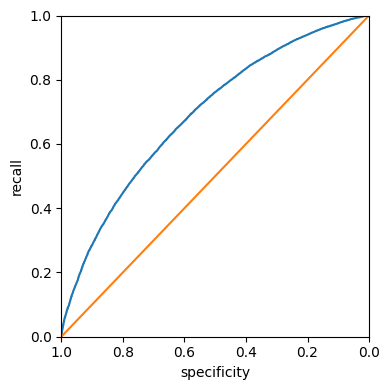

In [44]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:, 0], 
                                 pos_label='default')
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
ax.plot((1, 0), (0, 1))
ax.set_xlabel('specificity')
ax.set_ylabel('recall')


plt.tight_layout()
plt.show()

### R
R uses ROC tooling to inspect threshold sensitivity and specificity trade-offs.


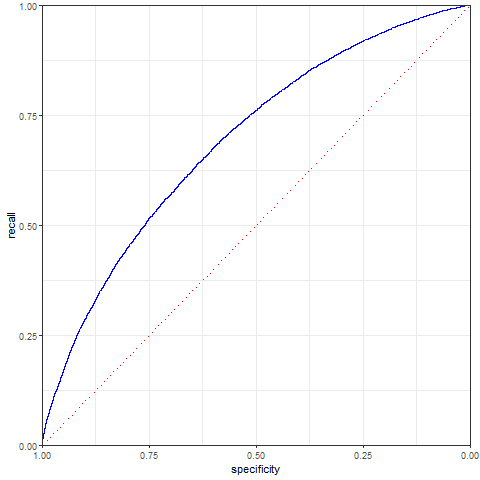

In [45]:
%%R
idx <- order(-pred)
recall <- cumsum(true_y[idx] == 1) / sum(true_y == 1)
specificity <- (sum(true_y == 0) - cumsum(true_y[idx] == 0)) / sum(true_y == 0)
roc_df <- data.frame(recall = recall, specificity = specificity)

graph <- ggplot(roc_df, aes(x=specificity, y=recall)) +
  geom_line(color='blue') + 
  scale_x_reverse(expand=c(0, 0)) +
  scale_y_continuous(expand=c(0, 0)) + 
  geom_line(data=data.frame(x=(0:100) / 100), aes(x=x, y=1-x),
            linetype='dotted', color='red') +
  theme_bw() + theme(plot.margin=unit(c(5.5, 10, 5.5, 5.5), "points"))
graph

### Summary: ROC Curve

| Operation | Python | R | Notes |
|---|---|---|---|
| ROC coordinates | `roc_curve()` | cumsum() on sorted predictions | Both compute TPR/FPR across thresholds. |
| Curve plotting | matplotlib/seaborn | base/ggplot ROC plotting | Equivalent visual comparison of threshold behavior. |
| Operating point | threshold selection from curve | threshold selection from curve | Both enable cost-sensitive threshold tuning. |

Python emphasizes explicit arrays for ROC coordinates; R often wraps computation and plotting in a single helper workflow.


## AUC

### Python
Accuracy can easily be calculated using the _scikit-learn_ function `accuracy_score`.

In [46]:
print(np.sum(roc_df.recall[:-1] * np.diff(1 - roc_df.specificity)))
print(roc_auc_score([1 if yi == 'default' else 0 for yi in y], logit_reg.predict_proba(X)[:, 0]))

0.6917107174637571
0.691710795288669


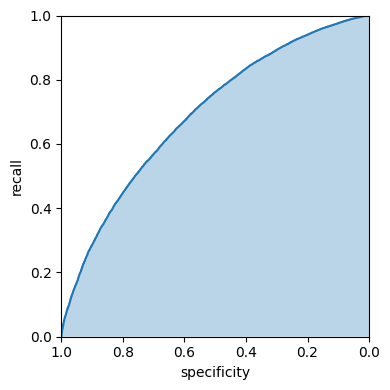

In [47]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:,0], 
                                 pos_label='default')
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
# ax.plot((1, 0), (0, 1))
ax.set_xlabel('specificity')
ax.set_ylabel('recall')
ax.fill_between(roc_df.specificity, 0, roc_df.recall, alpha=0.3)


plt.tight_layout()
plt.show()

### R
R computes AUC to summarize discriminative performance across thresholds.


In [48]:
%%R
sum(roc_df$recall[-1] * diff(1-roc_df$specificity))
head(roc_df)

        recall specificity
1 4.410921e-05   1.0000000
2 8.821843e-05   1.0000000
3 8.821843e-05   0.9999559
4 1.323276e-04   0.9999559
5 1.764369e-04   0.9999559
6 2.205461e-04   0.9999559


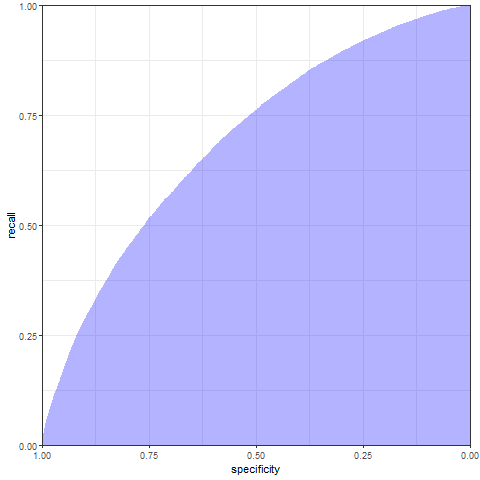

In [49]:
%%R
graph <- ggplot(roc_df, aes(specificity)) +
  geom_ribbon(aes(ymin=0, ymax=recall), fill='blue', alpha=.3) +
  scale_x_reverse(expand=c(0, 0)) +
  scale_y_continuous(expand=c(0, 0)) +
  labs(y='recall') +
  theme_bw() + theme(plot.margin=unit(c(5.5, 10, 5.5, 5.5), "points"))
graph

### Summary: AUC

| Operation | Python | R | Notes |
|---|---|---|---|
| AUC computation | `roc_auc_score()` | `sum(roc_df$recall[-1] * diff(1 - roc_df$specificity))` | Both summarize ranking quality into a scalar. |
| Model comparison | compare AUC across models | compare AUC across models | Same criterion for discrimination power. |
| Interpretation | probability-of-ranking framing | probability-of-ranking framing | Equivalent interpretation across ecosystems. |

AUC semantics are identical; API differences are mainly in where ROC objects and summaries are computed.


# Strategies for Imbalanced Data
## Undersampling

### Python
> The results differ from the R version, however are equivalent to results obtained using the R code. Model based results are of similar magnitude.

In [50]:
full_train_set = pd.read_csv(FULL_TRAIN_SET_CSV)
print(full_train_set.shape)

(119987, 19)


In [51]:
print('percentage of loans in default: ', 
print(      100 * np.mean(full_train_set.outcome == 'default')))

18.894546909248504
percentage of loans in default:  None


In [52]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 
              'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'
X = pd.get_dummies(full_train_set[predictors], prefix='', prefix_sep='', 
                   drop_first=True, dtype=int)
y = full_train_set[outcome]

full_model = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
full_model.fit(X, y)
print('percentage of loans predicted to default: ', 
print(      100 * np.mean(full_model.predict(X) == 'default')))

C:\Users\micha\Documents\to02DEC25\PyProjects\DS-GH\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


0.1525165226232842
percentage of loans predicted to default:  None


In [53]:
(np.mean(full_train_set.outcome == 'default') / 
 np.mean(full_model.predict(X) == 'default'))

np.float64(123.88524590163935)

### R
R applies balancing strategies to compare class predictions under skewed outcomes.


In [54]:
%%R
mean(full_train_set$outcome=='default')

full_model <- glm(outcome ~ payment_inc_ratio + purpose_ + home_ + 
                            emp_len_+ dti + revol_bal + revol_util,
                  data=full_train_set, family='binomial')
pred <- predict(full_model)
mean(pred > 0)

 mean(full_train_set$outcome=='default') / mean(pred > 0)

[1] 47.93023


### Summary: Strategies for Imbalanced Data

| Operation | Python | R | Notes |
|---|---|---|---|
| Class weighting | `class_weight` options | weight arguments in models | Both reweight minority class influence. |
| Sampling strategy | resampling utilities | resampling utilities | Both reduce imbalance bias at training time. |
| Metric focus | precision-recall oriented metrics | precision-recall oriented metrics | Both shift evaluation toward minority-class quality. |

Python often uses dedicated imbalance libraries plus sklearn, while R often composes balancing methods through formula-friendly packages.


## Oversampling and Up/Down Weighting

### Python
Python applies sampling or weighting strategies to rebalance minority and majority classes.


In [55]:
default_wt = 1 / np.mean(full_train_set.outcome == 'default')
wt = [default_wt if outcome == 'default' else 1 for outcome in full_train_set.outcome]

full_model = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model.fit(X, y, wt)
print('percentage of loans predicted to default (weighting): ', 
print(      100 * np.mean(full_model.predict(X) == 'default')))

C:\Users\micha\Documents\to02DEC25\PyProjects\DS-GH\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


61.475826547876025
percentage of loans predicted to default (weighting):  None


### R
R uses oversampling and weighting methods to rebalance training signals.


In [56]:
%%R
wt <- ifelse(full_train_set$outcome=='default', 
             1 / mean(full_train_set$outcome == 'default'), 1)
full_model <- glm(outcome ~ payment_inc_ratio + purpose_ + 
                  home_ + emp_len_+ dti + revol_bal + revol_util,
                  data=full_train_set, weight=wt, family='quasibinomial')
pred <- predict(full_model)
mean(pred > 0)

[1] 0.5767208


### Summary: Oversampling and Up/Down Weighting

| Operation | Python | R | Notes |
|---|---|---|---|
| Oversampling | synthetic/duplicate minority sampling | synthetic/duplicate minority sampling | Both increase minority representation. |
| Downsampling | majority subsampling | majority subsampling | Both reduce class skew in the training set. |
| Up/down weighting | sample weights | model weights | Both change loss emphasis without changing labels. |

Both ecosystems provide the same balancing levers; the practical difference is mostly package organization and defaults.


## Data Generation

### Python
The package _imbalanced-learn_ provides an implementation of the _SMOTE_ and similar algorithms. 

In [57]:
X_resampled, y_resampled = SMOTE().fit_resample(X, y)
print('percentage of loans in default (SMOTE resampled): ', 
      100 * np.mean(y_resampled == 'default'))

full_model = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model.fit(X_resampled, y_resampled)
print('percentage of loans predicted to default (SMOTE): ', 
      100 * np.mean(full_model.predict(X) == 'default'))


X_resampled, y_resampled = ADASYN().fit_resample(X, y)
print('percentage of loans in default (ADASYN resampled): ', 
      100 * np.mean(y_resampled == 'default'))

full_model = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model.fit(X_resampled, y_resampled)
print('percentage of loans predicted to default (ADASYN): ', 
print(      100 * np.mean(full_model.predict(X) == 'default')))

percentage of loans in default (SMOTE resampled):  50.0


C:\Users\micha\Documents\to02DEC25\PyProjects\DS-GH\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


percentage of loans predicted to default (SMOTE):  29.49069482527274
percentage of loans in default (ADASYN resampled):  48.56040383751355


C:\Users\micha\Documents\to02DEC25\PyProjects\DS-GH\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


27.340461883370697
percentage of loans predicted to default (ADASYN):  None


### R
R generates synthetic class-imbalance data for controlled method comparison.


In [58]:
%%R
loan_data_samp <- sample_frac(full_train_set, .05)

# # install.packages('unbalanced')
# library(unbalanced)
# head(full_train_set)
# smote_data <- ubSMOTE(loan_data_samp, loan_data_samp$outcome, 
#                       perc.over = 2000, k = 5, perc.under = 100)
# head(smote_data)

# install.packages('DMwR')
# library(DMwR)
# smote_data <- SMOTE(outcome ~ ., loan_data_samp, 
#                     perc.over = 2000, perc.under=100)
# dim(loan_data_samp)
# dim(smote_data)
# head(smote_data)

### Summary: Data Generation

| Operation | Python | R | Notes |
|---|---|---|---|
| Synthetic data setup | NumPy/Pandas generation | base R generation | Both create controlled imbalance scenarios. |
| Label process | explicit probability rules | explicit probability rules | Both allow transparent signal-to-noise tuning. |
| Validation use | benchmark balancing methods | benchmark balancing methods | Same objective for stress-testing classifiers. |

Python and R are equivalent for simulation tasks; Python tends toward array-centric construction, R toward concise vectorized expressions.


## Exploring the Predictions

### Python
Python visualizes and compares predicted probabilities under different balancing strategies.


In [59]:
loan3000 = pd.read_csv(LOAN3000_CSV)

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion='entropy', 
                                   min_impurity_decrease=0.003)
loan_tree.fit(X, y)

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)

logit_reg = LogisticRegression(penalty="l2", solver='liblinear')
logit_reg.fit(X, y)


## model
gam = LinearGAM(s(0) + s(1))
print(gam.gridsearch(X.values, [1 if yi == 'default' else 0 for yi in y]))

C:\Users\micha\Documents\to02DEC25\PyProjects\DS-GH\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + s(1) + intercept, 
   tol=0.0001, verbose=False)


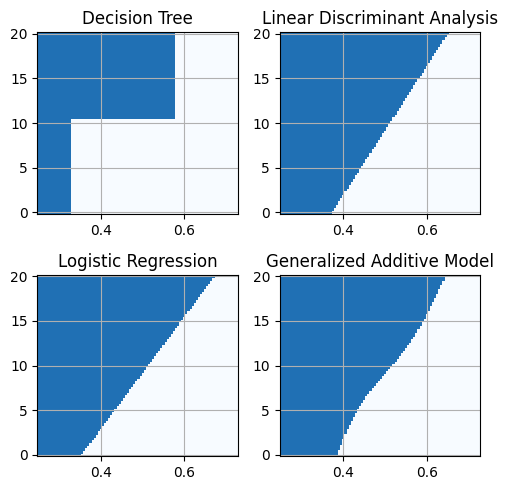

In [60]:
models = {
    'Decision Tree': loan_tree,
    'Linear Discriminant Analysis': loan_lda,
    'Logistic Regression': logit_reg,
    'Generalized Additive Model': gam,
}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))

xvalues = np.arange(0.25, 0.73, 0.005)
yvalues = np.arange(-0.1, 20.1, 0.1)
xx, yy = np.meshgrid(xvalues, yvalues)
X = pd.DataFrame({
    'borrower_score': xx.ravel(),
    'payment_inc_ratio': yy.ravel(),
})

boundary = {}

for n, (title, model) in enumerate(models.items()):
    ax = axes[n // 2, n % 2]
    predict = model.predict(X)
    if 'Generalized' in title:
        Z = np.array([1 if z > 0.5 else 0 for z in predict])
    else:
        
        Z = np.array([1 if z == 'default' else 0 for z in predict])
    Z = Z.reshape(xx.shape)
    boundary[title] = yvalues[np.argmax(Z > 0, axis=0)]
    boundary[title][Z[-1,:] == 0] = yvalues[-1]

    c = ax.pcolormesh(xx, yy, Z, cmap='Blues', vmin=0.1, vmax=1.3, shading='auto')
    ax.set_title(title)
    ax.grid(True)

plt.tight_layout()
plt.show()

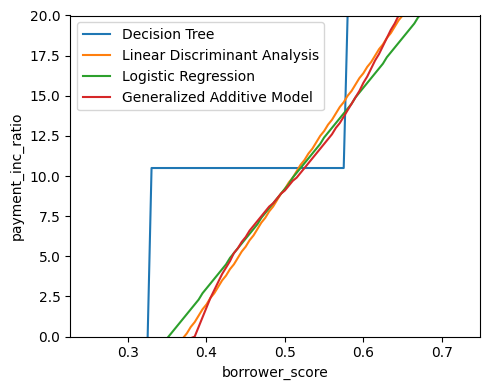

In [61]:
boundary['borrower_score'] = xvalues
boundaries = pd.DataFrame(boundary)

fig, ax = plt.subplots(figsize=(5, 4))
boundaries.plot(x='borrower_score', ax=ax)
ax.set_ylabel('payment_inc_ratio')
ax.set_ylim(0, 20)


plt.tight_layout()
plt.show()

### R
R visualizes predicted probabilities and classification behavior after rebalancing.


In [62]:
%%R
loan_tree <- rpart(outcome ~ borrower_score + payment_inc_ratio,
                   data=loan3000, 
                   control = rpart.control(cp=.005))

geom_abline(slope=slope, intercept=intercept, color='darkgreen')
lda_pred <- data.frame(borrower_score = c((0 - intercept) / slope, (20 - intercept) / slope),
                       payment_inc_ratio = c(0, 20),
                       method = rep('LDA', 2))

tree_pred <- data.frame(borrower_score = c(0.375, 0.375, 0.475, 0.475, 0.575, 0.575),
                        payment_inc_ratio = c(0, 4.426,  4.426, 10.42, 10.42, 20),
                        method = rep('Tree', 6))

glm0 <- glm(outcome ~ (payment_inc_ratio) +  (borrower_score),
            data=loan3000, family='binomial')
y <- seq(from=0, to=20, length=100)
x <- (-glm0$coefficients[1] - glm0$coefficients[2]*y)/glm0$coefficients[3]
glm0_pred <- data.frame(borrower_score=x, payment_inc_ratio=y, method='Logistic')

gam1 <- gam(outcome ~ s(payment_inc_ratio) +  s(borrower_score),
            data=loan3000, family='binomial')
gam_fun <- function(x){
  rss <- sum(predict(gam1, newdata=data.frame(borrower_score=x, payment_inc_ratio=y))^2)
}
est_x <- nlminb(seq(from=.33, to=.73, length=100), gam_fun )
gam1_pred <- data.frame(borrower_score=est_x$par, payment_inc_ratio=y, method="GAM")

loan_fits <- rbind(lda_pred,
                   tree_pred,
                   glm0_pred,
                   gam1_pred)

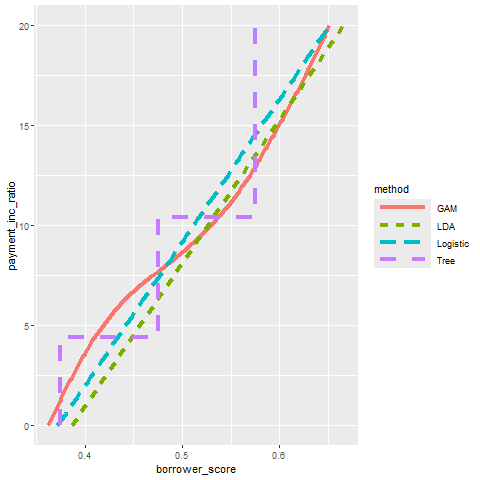

In [63]:
%%R
graph <- ggplot(data=loan_fits, aes(x=borrower_score, y=payment_inc_ratio, color=method, linetype=method)) +
  geom_line(size=1.5) +
  theme(legend.key.width = unit(2,"cm")) +
  guides(linetype = guide_legend(override.aes = list(size = 1)))
graph

### Summary: Exploring the Predictions

| Operation | Python | R | Notes |
|---|---|---|---|
| Probability distribution review | histograms/density by class | histograms/density by class | Both inspect separation quality visually. |
| Threshold impact | confusion trade-off checks | confusion trade-off checks | Both evaluate decision sensitivity to cutoff changes. |
| Method comparison | side-by-side prediction diagnostics | side-by-side prediction diagnostics | Both compare balancing strategies consistently. |

Both languages support the same interpretive diagnostics; differences are primarily in plotting APIs and helper function ecosystems.
